=== DATASET OVERVIEW ===
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area_SqFt  490 non-null    float64
 1   Rooms      500 non-null    int32  
 2   Age_Years  500 non-null    int32  
 3   Location   500 non-null    str    
 4   Price      500 non-null    float64
dtypes: float64(2), int32(2), str(1)
memory usage: 15.8 KB
None

=== NULL VALUE CHECK ===
Area_SqFt    10
Rooms         0
Age_Years     0
Location      0
Price         0
dtype: int64

=== DESCRIPTIVE STATISTICS ===


,Area_SqFt,Rooms,Age_Years,Price
count,490.000000,500.000000,500.00000,500.000000
mean,1797.404857,2.966000,24.50400,355010.206940
std,487.446691,1.422988,14.23655,90782.731971
min,500.000000,1.000000,0.00000,127459.410000
25%,1446.870000,2.000000,12.00000,290116.880000
50%,1803.870000,3.000000,24.50000,359971.525000
75%,2114.650000,4.000000,36.25000,417020.595000
max,3726.370000,5.000000,49.00000,639485.470000


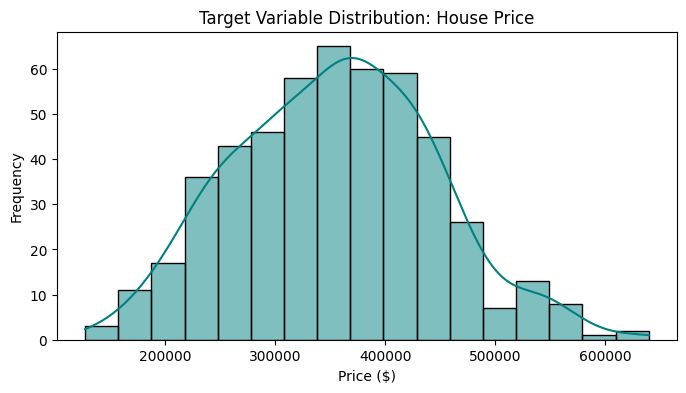

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)
n_samples = 500

# Generate synthetic house pricing data
area = np.random.normal(1800, 500, n_samples).clip(500, 4500)
rooms = np.random.randint(1, 6, n_samples)
age = np.random.randint(0, 50, n_samples)
location = np.random.choice(['Downtown', 'Suburbs', 'Rural'], n_samples, p=[0.3, 0.5, 0.2])

# Price formula with non-linear noise
price = (area * 150) + (rooms * 25000) - (age * 1200) + \
        np.where(location == 'Downtown', 80000, np.where(location == 'Suburbs', 30000, 0)) + \
        np.random.normal(0, 25000, n_samples)

df = pd.DataFrame({
    'Area_SqFt': np.round(area, 2),
    'Rooms': rooms,
    'Age_Years': age,
    'Location': location,
    'Price': np.round(price, 2)
})

# Inject a few missing values to demonstrate cleaning
df.loc[df.sample(frac=0.02, random_state=42).index, 'Area_SqFt'] = np.nan

print("=== DATASET OVERVIEW ===")
print(df.info())

print("\n=== NULL VALUE CHECK ===")
print(df.isnull().sum())

print("\n=== DESCRIPTIVE STATISTICS ===")
display(df.describe())

# Target Distribution Plot
plt.figure(figsize=(8, 4))
sns.histplot(df['Price'], kde=True, color='teal')
plt.title("Target Variable Distribution: House Price")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.show()

### Feature Selection Discussion
* **Area_SqFt:** Primary predictor of house size; directly correlates with higher market valuation.
* **Rooms:** Reflects space utility and capacity for larger households.
* **Age_Years:** Accounts for physical wear, design depreciation, and structural aging.
* **Location:** Neighborhood desirability and accessibility heavily drive real estate pricing.

In [2]:
# 1. Impute missing values with median
df['Area_SqFt'] = df['Area_SqFt'].fillna(df['Area_SqFt'].median())

# 2. One-Hot Encoding for categorical features
df_encoded = pd.get_dummies(df, columns=['Location'], drop_first=True)

print("=== CLEANED & ENCODED DATASET ===")
df_encoded.head()

=== CLEANED & ENCODED DATASET ===


,Area_SqFt,Rooms,Age_Years,Price,Location_Rural,Location_Suburbs
0,2048.36,2,9,378697.38,True,False
1,1730.87,2,29,371659.71,False,False
2,2123.84,3,24,391315.24,False,True
3,2561.51,3,38,413019.78,False,True
4,1682.92,5,19,379412.92,False,True


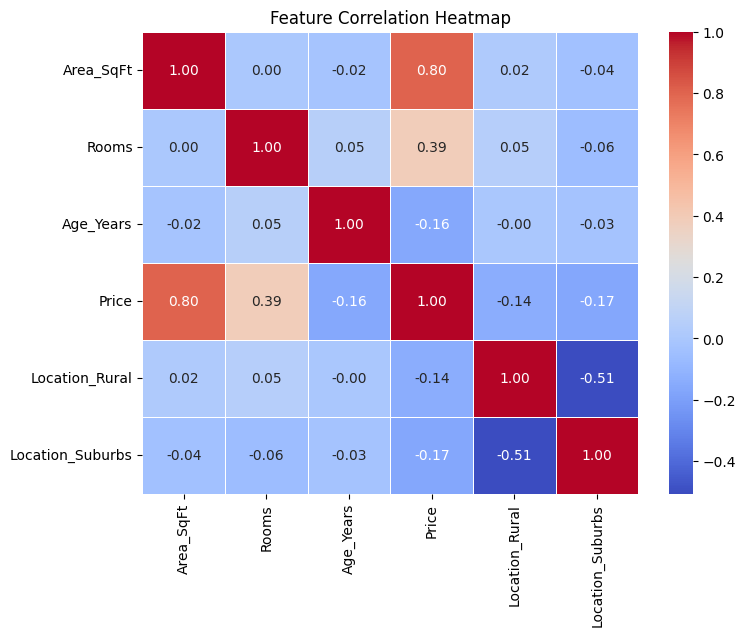

In [3]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features and Target
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred = lr_model.predict(X_test)

# Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== LINEAR REGRESSION PERFORMANCE ===")
print(f"Mean Squared Error (MSE) : ${mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score                  : {r2:.4f}")

=== LINEAR REGRESSION PERFORMANCE ===
Mean Squared Error (MSE) : $1,075,869,101.27
Root Mean Squared Error (RMSE): $32,800.44
R² Score                  : 0.8501


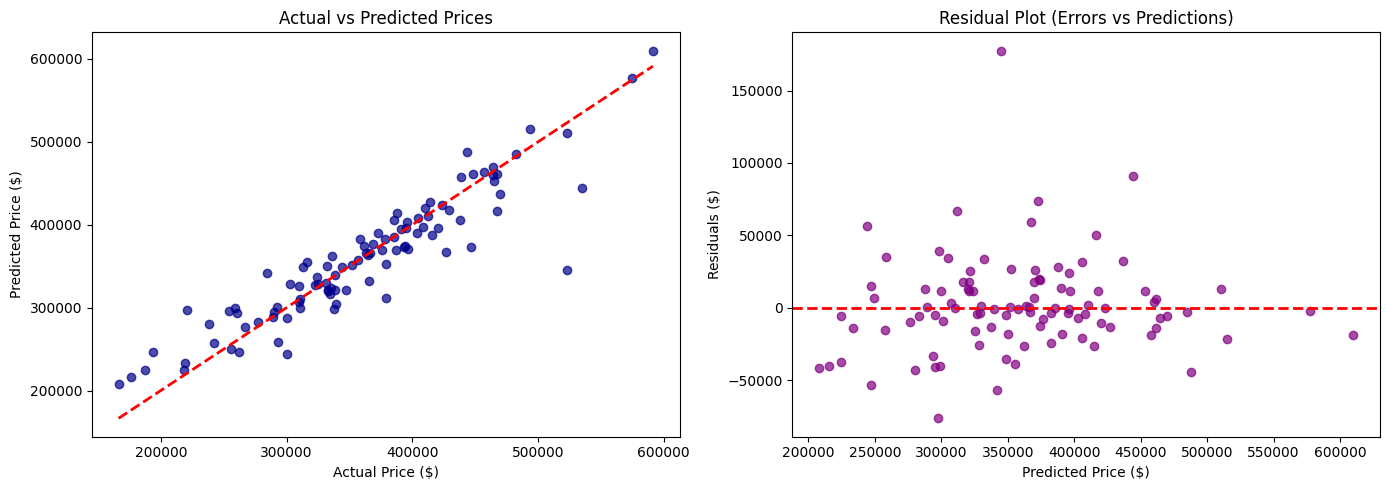

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted Scatter Plot
axes[0].scatter(y_test, y_pred, alpha=0.7, color='darkblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title("Actual vs Predicted Prices")
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")

# Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.7, color='purple')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_title("Residual Plot (Errors vs Predictions)")
axes[1].set_xlabel("Predicted Price ($)")
axes[1].set_ylabel("Residuals ($)")

plt.tight_layout()
plt.show()

=== FEATURE COEFFICIENT IMPACT ===


,Feature,Coefficient
1,Rooms,24416.508101
0,Area_SqFt,149.782668
2,Age_Years,-1116.079684
4,Location_Suburbs,-49396.415771
3,Location_Rural,-73596.930379


C:\Users\saadc\AppData\Local\Temp\ipykernel_18048\1847577616.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='magma')


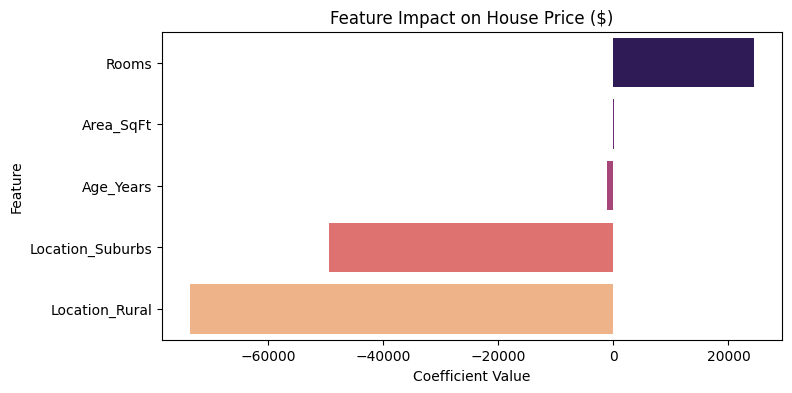

In [6]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("=== FEATURE COEFFICIENT IMPACT ===")
display(coef_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='magma')
plt.title("Feature Impact on House Price ($)")
plt.xlabel("Coefficient Value")
plt.show()

In [7]:
from sklearn.linear_model import Ridge, Lasso

# Regularized Models
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=100.0).fit(X_train, y_train)

comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'R² Score': [
        r2_score(y_test, lr_model.predict(X_test)),
        r2_score(y_test, ridge.predict(X_test)),
        r2_score(y_test, lasso.predict(X_test))
    ],
    'RMSE ($)': [
        np.sqrt(mean_squared_error(y_test, lr_model.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, ridge.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, lasso.predict(X_test)))
    ]
})

print("=== MODEL COMPARISON ===")
display(comparison_df)

=== MODEL COMPARISON ===


,Model,R² Score,RMSE ($)
0,Linear Regression,0.850119,32800.443614
1,Ridge Regression,0.850001,32813.346640
2,Lasso Regression,0.849915,32822.672120
